This notebook is for looking at the results of the tuning experiments.

In [22]:
# polars cant do hive partioning with json stuff
from pathlib import Path
from birdclef.spark import get_spark
import matplotlib.pyplot as plt

scratch = Path("~/scratch/birdclef/2025").expanduser()

spark = get_spark()


def show_results(path):
    score = (
        spark.read.json(
            f"{path}/logistic/train",
            multiLine=True,
        )
        .where("_corrupt_record IS NULL")
        .drop("_corrupt_record")
        .orderBy("tokenizer_n_clusters")
    )
    # score.show()

    timing = (
        spark.read.json(
            f"{path}/word2vec",
            multiLine=True,
        )
        .where("_corrupt_record IS NULL")
        .drop("_corrupt_record")
    )
    # timing.show()
    combined = score.join(
        timing,
        on=list(set(timing.columns).intersection(set(score.columns))),
        how="inner",
    )
    combined.show()
    return combined


tokenizer = show_results(f"{scratch}/mel2vec-tune/tokenizer")

25/06/18 05:22:48 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
25/06/18 05:22:49 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `epochs` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


+--------------------+---------+-----------+------+------+-----------+------+------------------+-------------------+------------------+------------------+-------+
|tokenizer_n_clusters|tokenizer|vector_size|window|sample|ns_exponent|epochs|          accuracy|     f1_macro_score|    f1_micro_score|              time|workers|
+--------------------+---------+-----------+------+------+-----------+------+------------------+-------------------+------------------+------------------+-------+
|               65535|tokenizer|        256|    80|1.0E-4|       0.75|    20|0.4873446847676024| 0.3893013389879503|0.4873446847676024|1507.9780993629247|      8|
|               16383|tokenizer|        256|    80|1.0E-4|       0.75|    20|0.5036815462494247|0.42931196578782665|0.5036815462494247|1046.1037343558855|      8|
|               32767|tokenizer|        256|    80|1.0E-4|       0.75|    20|0.4995398067188219| 0.4283813903213475|0.4995398067188219|1154.3622261900455|      8|
|                4096|

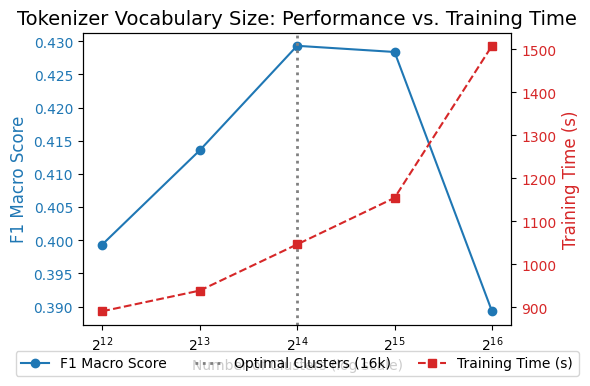

In [35]:
df = tokenizer.toPandas()

df = df.sort_values(by="tokenizer_n_clusters").reset_index(drop=True)


# Create plot
fig, ax1 = plt.subplots(figsize=(6, 4))

# Plot F1 Score on the primary y-axis
color = "tab:blue"
ax1.set_xlabel("Number of Clusters (log scale)")
ax1.set_ylabel("F1 Macro Score", color=color, fontsize=12)
ax1.plot(
    df["tokenizer_n_clusters"],
    df["f1_macro_score"],
    color=color,
    marker="o",
    label="F1 Macro Score",
)
ax1.tick_params(axis="y", labelcolor=color)
ax1.set_xscale("log", base=2)

# Instantiate a second y-axis sharing the same x-axis
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Training Time (s)", color=color, fontsize=12)
ax2.plot(
    df["tokenizer_n_clusters"],
    df["time"],
    color=color,
    marker="s",
    linestyle="--",
    label="Training Time (s)",
)
ax2.tick_params(axis="y", labelcolor=color)

# Highlight the optimal point
ax1.axvline(
    x=16383, color="grey", linestyle=":", linewidth=2, label="Optimal Clusters (16k)"
)

# Final touches
plt.title("Tokenizer Vocabulary Size: Performance vs. Training Time", fontsize=14)
# Consolidate legends from both axes into one.
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(
    lines + lines2,
    labels + labels2,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=3,
)

fig.tight_layout()

fig.set_size_inches(6, 4)
plt.savefig("tokenizer_vocab_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
strawman = show_results(f"{scratch}/mel2vec-strawman")

25/06/18 05:27:28 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `epochs` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


+--------------------+---------+-----------+------+------+-----------+------+------------------+-------------------+------------------+-----------------+-------+
|tokenizer_n_clusters|tokenizer|vector_size|window|sample|ns_exponent|epochs|          accuracy|     f1_macro_score|    f1_micro_score|             time|workers|
+--------------------+---------+-----------+------+------+-----------+------+------------------+-------------------+------------------+-----------------+-------+
|               16383|tokenizer|        256|    80|1.0E-4|       0.75|   100| 0.509894155545329|  0.427517704219526| 0.509894155545329|569.9089433640002|      8|
|               16383|tokenizer|        256|    80|1.0E-4|       0.75|    40|  0.50483202945237|0.43003987428418367|  0.50483202945237|557.8358309599571|      8|
|               16383|tokenizer|        256|    80|1.0E-4|       0.75|    30|0.5052922227335481|0.42661374387830964|0.5052922227335481|559.5936152609065|      8|
|               16383|tokeni

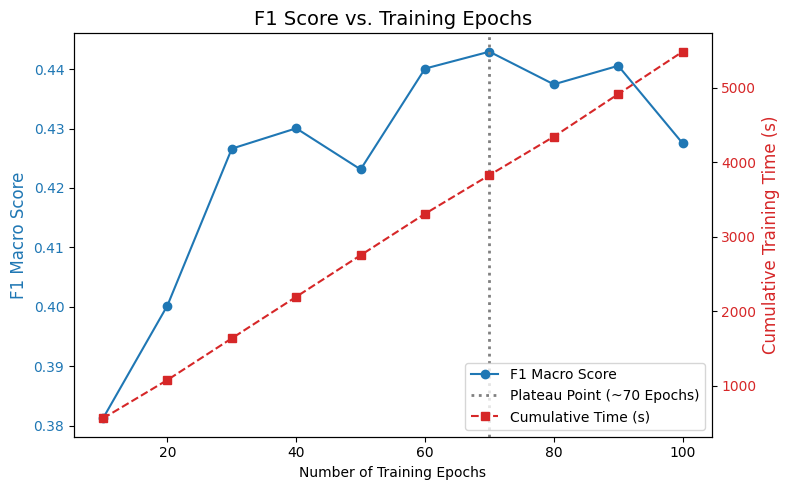

In [27]:
df = strawman.toPandas()

df = df.sort_values(by="epochs").reset_index(drop=True)

# Create the plot
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot F1 Score on the primary y-axis
color = "tab:blue"
ax1.set_xlabel("Number of Training Epochs")
ax1.set_ylabel("F1 Macro Score", color=color, fontsize=12)
ax1.plot(
    df["epochs"], df["f1_macro_score"], color=color, marker="o", label="F1 Macro Score"
)
ax1.tick_params(axis="y", labelcolor=color)

# Instantiate a second y-axis for time - notice the time data is noisy, but shows a general trend
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Cumulative Training Time (s)", color=color, fontsize=12)
# To make the time plot meaningful, we calculate the cumulative time
df["cumulative_time"] = df["time"].cumsum()
ax2.plot(
    df["epochs"],
    df["cumulative_time"],
    color=color,
    marker="s",
    linestyle="--",
    label="Cumulative Time (s)",
)
ax2.tick_params(axis="y", labelcolor=color)

# Highlight the plateau area
ax1.axvline(
    x=70, color="grey", linestyle=":", linewidth=2, label="Plateau Point (~70 Epochs)"
)

# Final Touches
plt.title("F1 Score vs. Training Epochs", fontsize=14)
# Consolidate legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc="lower right")

fig.tight_layout()

In [28]:
search = show_results(f"{scratch}/mel2vec-tune/w2v")

25/06/18 05:28:03 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `epochs` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


+--------------------+---------+-----------+------+------+-----------+------+-------------------+-------------------+-------------------+------------------+-------+
|tokenizer_n_clusters|tokenizer|vector_size|window|sample|ns_exponent|epochs|           accuracy|     f1_macro_score|     f1_micro_score|              time|workers|
+--------------------+---------+-----------+------+------+-----------+------+-------------------+-------------------+-------------------+------------------+-------+
|               16383|tokenizer|        256|   120|1.0E-4|       0.75|    20| 0.5108145421076852| 0.4271896635306308| 0.5108145421076852|1480.2317122467794|      8|
|               16383|tokenizer|        256|   120|1.0E-4|       -0.5|    20| 0.5050621260929591|0.40525111404959935| 0.5050621260929591| 1470.953366188798|      8|
|               16383|tokenizer|        512|    80|1.0E-4|       0.75|    20| 0.5446387482742752|0.44504761526763714| 0.5446387482742752|1673.5793089400977|      8|
|         

In [30]:
ns = show_results(f"{scratch}/mel2vec-tune/ns")

25/06/18 05:58:17 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `epochs` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


+--------------------+---------+-----------+------+------+-----------+------+------------------+-------------------+------------------+------------------+-------+
|tokenizer_n_clusters|tokenizer|vector_size|window|sample|ns_exponent|epochs|          accuracy|     f1_macro_score|    f1_micro_score|              time|workers|
+--------------------+---------+-----------+------+------+-----------+------+------------------+-------------------+------------------+------------------+-------+
|               16383|tokenizer|        384|    80|1.0E-5|      -1.25|    20|0.5306028531983433|0.44986494777160885|0.5306028531983433| 620.7715839692391|      8|
|               16383|tokenizer|        384|    80|1.0E-5|      -0.75|    20|0.5278416935112747| 0.4571958766014901|0.5278416935112747| 651.1663765879348|      8|
|               16383|tokenizer|        384|    80|1.0E-5|      -0.25|    20|0.5280717901518638|0.44015800774347735|0.5280717901518638| 666.2988879359327|      8|
|               16383|

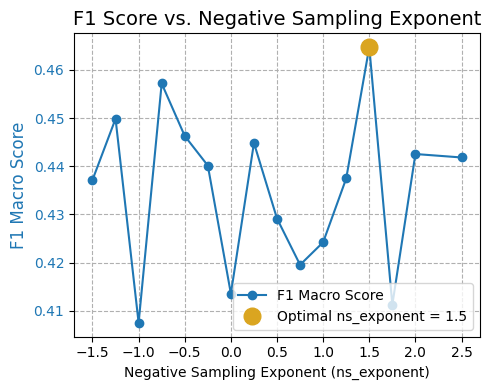

In [36]:
df = ns.toPandas()
# Sort by ns_exponent to ensure the line plot connects points correctly
df = df.sort_values(by="ns_exponent").reset_index(drop=True)

# Create the plot
fig, ax1 = plt.subplots(figsize=(5, 4))

# Plot F1 Score
color = "tab:blue"
ax1.set_xlabel("Negative Sampling Exponent (ns_exponent)")
ax1.set_ylabel("F1 Macro Score", color=color, fontsize=12)
ax1.plot(
    df["ns_exponent"],
    df["f1_macro_score"],
    color=color,
    marker="o",
    label="F1 Macro Score",
)
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, which="both", linestyle="--")

# Highlight the optimal point
optimal_ns = 1.5
optimal_f1 = df[df["ns_exponent"] == optimal_ns]["f1_macro_score"].iloc[0]
ax1.plot(
    optimal_ns,
    optimal_f1,
    "o",
    markersize=12,
    color="goldenrod",
    label=f"Optimal ns_exponent = {optimal_ns}",
)

# Final Touches
plt.title("F1 Score vs. Negative Sampling Exponent", fontsize=14)
ax1.legend(loc="lower right")

fig.tight_layout()
fig.set_size_inches(5, 4)
plt.savefig("ns_exponent_tuning_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
v1 = show_results(f"{scratch}/mel2vec-v1")

25/06/18 05:16:20 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `epochs` already exists. Choose another name or rename the existing column. SQLSTATE: 42711


+--------------------+---------+-----------+------+------+-----------+------+------------------+-------------------+------------------+------------------+-------+
|tokenizer_n_clusters|tokenizer|vector_size|window|sample|ns_exponent|epochs|          accuracy|     f1_macro_score|    f1_micro_score|              time|workers|
+--------------------+---------+-----------+------+------+-----------+------+------------------+-------------------+------------------+------------------+-------+
|               16383|tokenizer|        384|    80|1.0E-5|        1.5|   100| 0.534054302807179| 0.4484265528088365| 0.534054302807179|281.00293850013986|      8|
|               16383|tokenizer|        384|    80|1.0E-5|        1.5|    60|0.5269213069489186|0.42255132143405466|0.5269213069489186|278.57246231706813|      8|
|               16383|tokenizer|        384|    80|1.0E-5|        1.5|    70|0.5354348826507133| 0.4521408599169795|0.5354348826507133|263.06446097092703|      8|
|               16383|

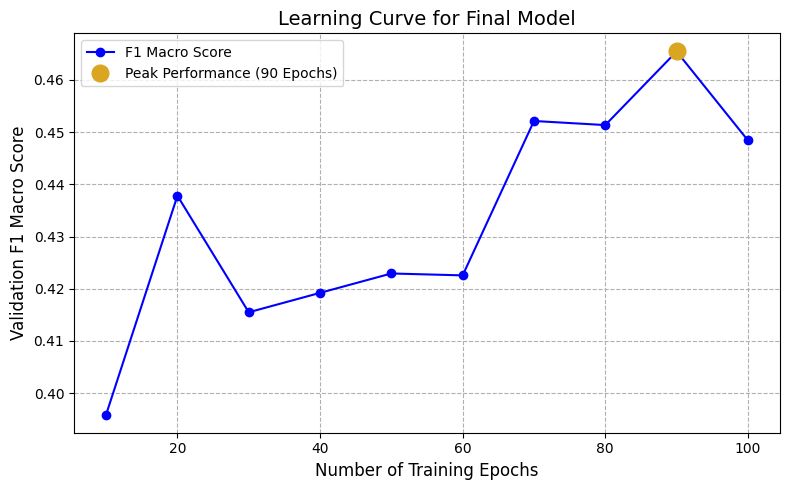

In [32]:
df = v1.toPandas()

# Sort by epochs to create a smooth curve
df = df.sort_values(by="epochs").reset_index(drop=True)

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot F1 Score vs. Epochs
ax.plot(
    df["epochs"],
    df["f1_macro_score"],
    marker="o",
    linestyle="-",
    color="b",
    label="F1 Macro Score",
)

# Highlight the optimal point
optimal_epoch = 90
optimal_f1 = df[df["epochs"] == optimal_epoch]["f1_macro_score"].iloc[0]
ax.plot(
    optimal_epoch,
    optimal_f1,
    "o",
    markersize=12,
    color="goldenrod",
    label="Peak Performance (90 Epochs)",
)

# Labels and Title
ax.set_xlabel("Number of Training Epochs", fontsize=12)
ax.set_ylabel("Validation F1 Macro Score", fontsize=12)
ax.set_title("Learning Curve for Final Model", fontsize=14)
ax.legend()
ax.grid(True, which="both", linestyle="--")

plt.tight_layout()

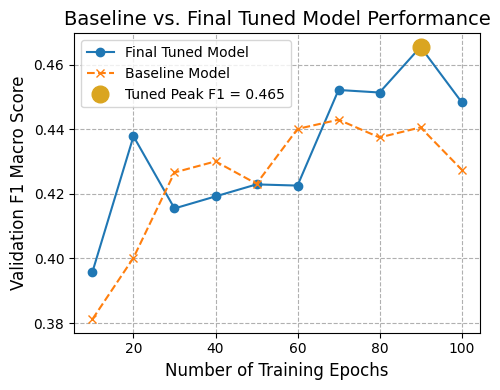

In [41]:
df1 = strawman.toPandas()
df2 = v1.toPandas()
df1 = df1.sort_values(by="epochs").reset_index(drop=True)
df2 = df2.sort_values(by="epochs").reset_index(drop=True)

# Create the plot
fig, ax = plt.subplots(figsize=(5, 4))

# Plot both learning curves
ax.plot(
    df2["epochs"],
    df2["f1_macro_score"],
    marker="o",
    linestyle="-",
    # color="blue",
    label="Final Tuned Model",
)

ax.plot(
    df1["epochs"],
    df1["f1_macro_score"],
    marker="x",
    linestyle="--",
    # color="grey",
    label="Baseline Model",
)

# Highlight the peak performance of the final model
optimal_epoch = 90
optimal_f1 = df2[df2["epochs"] == optimal_epoch]["f1_macro_score"].iloc[0]
ax.plot(
    optimal_epoch,
    optimal_f1,
    "o",
    markersize=12,
    color="goldenrod",
    label=f"Tuned Peak F1 = {optimal_f1:.3f}",
)


# Labels and Title
ax.set_xlabel("Number of Training Epochs", fontsize=12)
ax.set_ylabel("Validation F1 Macro Score", fontsize=12)
ax.set_title("Baseline vs. Final Tuned Model Performance", fontsize=14)
ax.legend()
ax.grid(True, which="both", linestyle="--")

plt.tight_layout()
fig.set_size_inches(5, 4)
plt.savefig("comparison_learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()